# Análise de faculdades globais

# Tratamento dos dados

## Bibliotecas que serão usadas

In [215]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Criando dataset

In [216]:
dataset = pd.read_csv('College Data.csv')
pd.set_option('display.max_columns', None)
dataset

,College ID,Country,Total Students,Male,Female,CGPA,Annual Family Income,Branch,Sports,Research Papers Published,Placement Rate,Faculty Count
0,College 52,UK,27002,2593,11644,10.000000,3574250,Physics,Swimming,39,100.00,655
1,College 93,Switzerland,11913,9392,2521,6.951278,762556,Chemical Engineering,Athletics,31,68.84,256
2,College 15,Japan,15644,5475,4388,9.327922,1795845,Business Administration,Volleyball,37,91.99,555
3,College 72,Singapore,13239,7363,5876,8.681112,1222223,Physics,Tennis,48,97.98,455
4,College 61,Canada,10236,13339,-3103,8.560567,1921133,Biotechnology,Athletics,34,83.56,310
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,College 93,India,14676,10771,3905,8.335598,3151197,Civil Engineering,Cricket,20,65.61,596
49996,College 48,Japan,21908,10682,6820,8.490003,3060006,Physics,Chess,9,99.15,383
49997,College 67,South Africa,17263,11035,6228,5.979781,1519563,Chemical Engineering,Athletics,35,78.28,671
49998,College 54,USA,11371,10233,1138,7.714894,2429788,Mechanical Engineering,Swimming,11,88.46,164


## Tratamento do dataset
Aqui renomearemos colunas, formataremos dados para melhor compreensão e removeremos erros contidos no dataset.

In [217]:
renomear_colunas = ['Faculdade ID', 'Pais', 'Total_Estudantes', 'Estudantes_Masculinos', 'Estudantes_Femininas', 'CGPA',
       'Renda_Familiar_Anual', 'Curso', 'Esportes', 'Pesquisas_Publicadas', 'Taxa_Formados_Empregados', 'Número_Professores']
dataset.columns = renomear_colunas

dataset['CGPA'] = dataset["CGPA"].round(1)
dataset['Taxa_Formados_Empregados'] = pd.to_numeric(dataset['Taxa_Formados_Empregados'], errors='coerce')

dataset['Estudantes_Femininas'] = dataset['Estudantes_Femininas'].abs()

In [218]:
traducao_cursos = {
    'Chemical Engineering': 'Engenharia Química',
    'Physics': 'Física',
    'Electrical Engineering': 'Engenharia Elétrica',
    'Biotechnology': 'Biotecnologia',
    'Economics': 'Economia',
    'Civil Engineering': 'Engenharia Civil',
    'Business Administration': 'Administração de Empresas',
    'Mechanical Engineering': 'Engenharia Mecânica',
    'Computer Science': 'Ciência da Computação',
    'Mathematics': 'Matemática'
}

traducao_esportes = {
    'Swimming': 'Natação',
    'Athletics': 'Atletismo',
    'Volleyball': 'Vôlei',
    'Tennis': 'Tênis',
    'Basketball': 'Basquete',
    'Football': 'Futebol',
    'Badminton': 'Badminton',
    'Cricket': 'Críquete',
    'Chess': 'Xadrez'
}

traducao_paises = {
    'Switzerland': 'Suíça',
    'Singapore': 'Singapura',
    'Japan': 'Japão',
    'China': 'China',
    'Canada': 'Canadá',
    'UK': 'Reino Unido',
    'Australia': 'Austrália',
    'India': 'Índia',
    'South Africa': 'África do Sul',
    'USA': 'Estados Unidos'
}

dataset['Pais'] = dataset['Pais'].replace(traducao_paises)
dataset['Esportes'] = dataset['Esportes'].replace(traducao_esportes)
dataset['Curso'] = dataset['Curso'].replace(traducao_cursos)

## Visualizando o dataset após o tratamento dos dados

In [219]:
dataset

,Faculdade ID,Pais,Total_Estudantes,Estudantes_Masculinos,Estudantes_Femininas,CGPA,Renda_Familiar_Anual,Curso,Esportes,Pesquisas_Publicadas,Taxa_Formados_Empregados,Número_Professores
0,College 52,Reino Unido,27002,2593,11644,10.0,3574250,Física,Natação,39,100.00,655
1,College 93,Suíça,11913,9392,2521,7.0,762556,Engenharia Química,Atletismo,31,68.84,256
2,College 15,Japão,15644,5475,4388,9.3,1795845,Administração de Empresas,Vôlei,37,91.99,555
3,College 72,Singapura,13239,7363,5876,8.7,1222223,Física,Tênis,48,97.98,455
4,College 61,Canadá,10236,13339,3103,8.6,1921133,Biotecnologia,Atletismo,34,83.56,310
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,College 93,Índia,14676,10771,3905,8.3,3151197,Engenharia Civil,Críquete,20,65.61,596
49996,College 48,Japão,21908,10682,6820,8.5,3060006,Física,Xadrez,9,99.15,383
49997,College 67,África do Sul,17263,11035,6228,6.0,1519563,Engenharia Química,Atletismo,35,78.28,671
49998,College 54,Estados Unidos,11371,10233,1138,7.7,2429788,Engenharia Mecânica,Natação,11,88.46,164


### Informações do dataset
Aqui veremos quantas linhas não nulas o dataset possuí e o tipo de dados de cada coluna

In [220]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Faculdade ID              50000 non-null  object 
 1   Pais                      50000 non-null  object 
 2   Total_Estudantes          50000 non-null  int64  
 3   Estudantes_Masculinos     50000 non-null  int64  
 4   Estudantes_Femininas      50000 non-null  int64  
 5   CGPA                      50000 non-null  float64
 6   Renda_Familiar_Anual      50000 non-null  int64  
 7   Curso                     50000 non-null  object 
 8   Esportes                  50000 non-null  object 
 9   Pesquisas_Publicadas      50000 non-null  int64  
 10  Taxa_Formados_Empregados  50000 non-null  float64
 11  Número_Professores        50000 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 4.6+ MB


### Descrição dos dados
Aqui temos uma breve descrição estatistica dos dados númericos, como média de valor das colunas, desvio padrão, seus valores mínimos e máximos.

In [221]:
dataset.describe().round(1)

,Total_Estudantes,Estudantes_Masculinos,Estudantes_Femininas,CGPA,Renda_Familiar_Anual,Pesquisas_Publicadas,Taxa_Formados_Empregados,Número_Professores
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,15522.4,7747.1,5721.7,8.7,2611605.6,24.5,82.3,428.9
std,8366.8,4188.4,3824.0,1.1,1387889.0,14.5,11.5,154.7
min,1001.0,500.0,0.0,4.0,200004.0,0.0,60.0,62.0
25%,8272.8,4111.0,2487.0,8.0,1408785.5,12.0,72.4,315.0
50%,15506.5,7756.0,5112.0,8.8,2620902.5,24.0,82.5,428.0
75%,22768.2,11360.0,8504.0,9.7,3811208.5,37.0,92.5,544.0
max,29999.0,14999.0,14999.0,10.0,4999988.0,49.0,100.0,796.0


# Análises Estatísticas

## Analisando por estudantes

### Quantidade geral de estudante por país

In [222]:
qtd_estud_pais = dataset.groupby('Pais')['Total_Estudantes'].sum().reset_index()
qtd_estud_pais.sort_values(by='Total_Estudantes',ascending=False)

,Pais,Total_Estudantes
2,China,78785524
8,África do Sul,78611487
7,Suíça,78233472
6,Singapura,77965255
0,Austrália,77368139
3,Estados Unidos,77299951
4,Japão,77166258
1,Canadá,77057301
9,Índia,76900811
5,Reino Unido,76729674


### Quantidade de estudante por gênero

In [223]:
qtd_estud_masc_pais = dataset.groupby('Pais')['Estudantes_Masculinos'].sum().reset_index()
qtd_estud_masc_pais.sort_values(by='Estudantes_Masculinos',ascending=False)

,Pais,Estudantes_Masculinos
8,África do Sul,39302765
2,China,39101368
0,Austrália,39020306
3,Estados Unidos,38865321
7,Suíça,38792394
6,Singapura,38670432
1,Canadá,38596759
4,Japão,38573411
9,Índia,38468236
5,Reino Unido,37962103


In [224]:
qtd_estud_masc_pais = dataset.groupby('Pais')['Estudantes_Femininas'].sum().reset_index()
qtd_estud_masc_pais.sort_values(by='Estudantes_Femininas',ascending=False)

,Pais,Estudantes_Femininas
2,China,29516477
3,Estados Unidos,28842841
0,Austrália,28832090
7,Suíça,28796949
1,Canadá,28733336
6,Singapura,28447927
4,Japão,28399963
8,África do Sul,28344085
9,Índia,28161373
5,Reino Unido,28008096


### Porcentagem de estudantes por gênero

In [225]:
porcent_masc = (dataset.groupby('Pais')['Estudantes_Masculinos'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_masc = porcent_masc.round(2).to_frame()
porcent_masc.columns = ['Porcentagem de estudantes do sexo masculino']
porcent_masc

,Porcentagem de estudantes do sexo masculino
Pais,
Austrália,50.43
Canadá,50.09
China,49.63
Estados Unidos,50.28
Japão,49.99
Reino Unido,49.48
Singapura,49.60
Suíça,49.59
África do Sul,50.00


In [226]:
porcent_femen = (dataset.groupby('Pais')['Estudantes_Femininas'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_femen = porcent_femen.round(2).to_frame()
porcent_femen.columns = ['Porcentagem de estudantes do sexo feminino']
porcent_femen

,Porcentagem de estudantes do sexo feminino
Pais,
Austrália,37.27
Canadá,37.29
China,37.46
Estados Unidos,37.31
Japão,36.80
Reino Unido,36.50
Singapura,36.49
Suíça,36.81
África do Sul,36.06


Opa, podemos notar que ao somar as porcetagens de estudantes por gênero não conseguimos chegar a 100% da quantidade de estudantes daquele país, vamos averiguar.

#### Hipótese
acredito que há universidades em que a quantidade total de estudantes não é o mesmo valor que o da soma entre a quantidade de estudantes masculinos e femininos, fazendo a universidade ter um certo 'gap' que não é preenchido

In [227]:
dataset[(dataset['Estudantes_Femininas'] + dataset['Estudantes_Masculinos']) != dataset['Total_Estudantes']]

,Faculdade ID,Pais,Total_Estudantes,Estudantes_Masculinos,Estudantes_Femininas,CGPA,Renda_Familiar_Anual,Curso,Esportes,Pesquisas_Publicadas,Taxa_Formados_Empregados,Número_Professores
0,College 52,Reino Unido,27002,2593,11644,10.0,3574250,Física,Natação,39,100.00,655
2,College 15,Japão,15644,5475,4388,9.3,1795845,Administração de Empresas,Vôlei,37,91.99,555
4,College 61,Canadá,10236,13339,3103,8.6,1921133,Biotecnologia,Atletismo,34,83.56,310
5,College 21,Estados Unidos,22804,4373,2757,9.1,1885655,Engenharia Química,Basquete,30,85.50,439
6,College 83,Reino Unido,8135,11111,2976,6.9,1191708,Biotecnologia,Vôlei,21,76.13,282
...,...,...,...,...,...,...,...,...,...,...,...,...
49989,College 73,Reino Unido,27394,4720,8287,8.2,1731532,Ciência da Computação,Xadrez,31,84.72,604
49990,College 56,Suíça,9287,6309,912,10.0,4018482,Economia,Críquete,24,75.21,556
49991,College 6,Austrália,22435,10439,10369,7.9,1435003,Engenharia Civil,Basquete,12,73.44,668
49992,College 28,Austrália,15347,5114,6299,10.0,1916342,Ciência da Computação,Críquete,15,85.33,360


Há 36566 universidades em que isso acontece, essa imprecissão nos dados não nos será útil, então ajustaremos o dataset a fim de termos mais precissão em nossos dados.

In [228]:
dataset = dataset.copy()

dataset['Total_Estudantes'] = (dataset['Estudantes_Femininas'] + dataset['Estudantes_Masculinos'])

Agora que corrigimos a quantidade total de estudantes do dataset, vamos iniciar algumas análises para vermos a diferença na quantidade de estudantes após a filtragem:

In [229]:
qtd_estud_pais = dataset.groupby('Pais')['Total_Estudantes'].sum().reset_index()
qtd_estud_pais.sort_values(by='Total_Estudantes',ascending=False)

,Pais,Total_Estudantes
2,China,68617845
0,Austrália,67852396
3,Estados Unidos,67708162
8,África do Sul,67646850
7,Suíça,67589343
1,Canadá,67330095
6,Singapura,67118359
4,Japão,66973374
9,Índia,66629609
5,Reino Unido,65970199


podemos notar a queda drástica no número de estudantes por país, sendo que anteriormente tínhamos 78785524 estudantes na china e agora só temos 16556804, tendo uma perca de cerga de 62228720 estudantes. Agora, vamos averiguar a diferença entre a quantidade de estudantes dos sexos femininos e masculinos:

In [230]:
porcent_femen = (dataset.groupby('Pais')['Estudantes_Femininas'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_femen = porcent_femen.round(2).to_frame()
porcent_femen.columns = ['Porcentagem de estudantes do sexo feminino']
porcent_femen

,Porcentagem de estudantes do sexo feminino
Pais,
Austrália,42.49
Canadá,42.68
China,43.02
Estados Unidos,42.60
Japão,42.40
Reino Unido,42.46
Singapura,42.38
Suíça,42.61
África do Sul,41.90


In [231]:
porcent_masc = (dataset.groupby('Pais')['Estudantes_Masculinos'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_masc = porcent_masc.round(2).to_frame()
porcent_masc.columns = ['Porcentagem de estudantes do sexo masculino']
porcent_masc

,Porcentagem de estudantes do sexo masculino
Pais,
Austrália,57.51
Canadá,57.32
China,56.98
Estados Unidos,57.40
Japão,57.60
Reino Unido,57.54
Singapura,57.62
Suíça,57.39
África do Sul,58.10


Podemos concluir que realmente se tem muito mais estudantes do sexo masculino do que feminino nas universidades.

## Analises por universidades

### Avaliação média das das universidades de cada país

In [232]:
media_cgpa = dataset.groupby('Pais')['CGPA'].mean().round(2).reset_index()
media_cgpa.sort_values(by='CGPA', ascending=False)

,Pais,CGPA
1,Canadá,8.73
2,China,8.72
9,Índia,8.72
7,Suíça,8.71
6,Singapura,8.71
5,Reino Unido,8.71
4,Japão,8.70
3,Estados Unidos,8.70
0,Austrália,8.69
8,África do Sul,8.68


Podemos notar que as universidades da India, China e Canada possuem as universidades com melhores notas. Agora verifiquemos quantas paises possuem mais universidades.

### Quantidade de universidades por país

In [233]:
qtd_universid_pais = dataset['Pais'].value_counts().to_frame()
qtd_universid_pais.columns = ['Quantidade de faculdades']
qtd_universid_pais = qtd_universid_pais.sort_values(by='Quantidade de faculdades',ascending=False)
qtd_universid_pais


,Quantidade de faculdades
Pais,
China,5052
África do Sul,5052
Suíça,5025
Austrália,5018
Singapura,5013
Japão,4991
Estados Unidos,4985
Canadá,4974
Reino Unido,4945


Podemos notar que os países com maiores quantidades de faculdades possuem uma média de nota CGPA inferior ao países com menos faculdades, implicando que quantidade não é igual qualidade de ensino, exceto pela China.

### Quantidade média de estudante por universidade

In [234]:
media_estud_por_univers = (dataset.groupby('Pais')['Total_Estudantes'].sum() / dataset['Pais'].value_counts())
media_estud_por_univers = media_estud_por_univers.round(0).astype(int).to_frame()
media_estud_por_univers.columns = ['Quantidade média de estudante por universidade']
media_estud_por_univers.sort_values(by='Quantidade média de estudante por universidade',ascending=False)

,Quantidade média de estudante por universidade
Pais,
Estados Unidos,13582
China,13582
Canadá,13536
Austrália,13522
Índia,13474
Suíça,13451
Japão,13419
África do Sul,13390
Singapura,13389


Todas as univeridades possuem em média cerca de 13 mil estudantes.

### Quantidade média de professores por universidade

In [235]:
media_prof_univers = dataset.groupby('Pais')['Número_Professores'].mean()
media_prof_univers = media_prof_univers.round(0).astype(int).to_frame()
media_prof_univers.columns = ['Quantidade média de professores por faculdade']
media_prof_univers.sort_values(by='Quantidade média de professores por faculdade',ascending=False)

,Quantidade média de professores por faculdade
Pais,
Austrália,430
China,430
Índia,430
Estados Unidos,430
Singapura,430
Suíça,429
Canadá,428
Reino Unido,428
Japão,427


Todas as universidades possuem em média 430 professores.

### Quantidade de média de aluno por turma

In [236]:
media_aluno_turma = (dataset.groupby('Pais')['Total_Estudantes'].sum() / dataset.groupby('Pais')['Número_Professores'].sum())
media_aluno_turma = media_aluno_turma.round(0).to_frame().astype(int)
media_aluno_turma.columns = ['Media de alunos por turma']
media_aluno_turma.sort_values(by='Media de alunos por turma',ascending=False)

,Media de alunos por turma
Pais,
Canadá,32
China,32
Estados Unidos,32
Austrália,31
Japão,31
Reino Unido,31
Singapura,31
Suíça,31
África do Sul,31


### Quantidade média de pesquisas publicada por faculdades de cada país

In [237]:
media_pesq_facul = dataset.groupby('Pais')['Pesquisas_Publicadas'].mean()
media_pesq_facul = media_pesq_facul.round(0).to_frame().astype(int)
media_pesq_facul.columns = ['Media de alunos por turma']
media_pesq_facul.sort_values(by='Media de alunos por turma',ascending=False)

,Media de alunos por turma
Pais,
Canadá,25
Estados Unidos,25
África do Sul,25
Japão,25
Suíça,25
Austrália,24
Reino Unido,24
China,24
Singapura,24


## Análise por Curso

### Quantidade de Cursos ofertados por país
Aqui veremos quais aréas de conhecimentos mais presentes nas faculdades de cada país

In [238]:
qtd_cursos_pais = (
    dataset.pivot_table(index='Pais', columns='Curso', values='Faculdade ID', aggfunc='count', fill_value=0)
    .reset_index()
)

qtd_cursos_pais

Curso,Pais,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
0,Austrália,494,506,493,465,511,492,501,546,509,501
1,Canadá,503,480,502,481,465,498,485,532,507,521
2,China,488,520,561,508,513,475,442,521,505,519
3,Estados Unidos,478,515,460,500,497,513,499,520,490,513
4,Japão,484,493,455,473,528,518,514,491,509,526
5,Reino Unido,493,488,513,461,467,522,489,476,511,525
6,Singapura,507,481,491,493,489,518,473,521,531,509
7,Suíça,505,512,504,471,529,493,504,527,510,470
8,África do Sul,511,500,513,468,512,495,531,489,498,535
9,Índia,493,485,516,487,487,494,486,509,539,449


#### Qual curso mais ofertado de cada país?

In [239]:
qtd_cursos_pais['Curso Mais Presente'] = qtd_cursos_pais.iloc[:, 1:].idxmax(axis=1)
qtd_cursos_pais['Quantidade'] = qtd_cursos_pais.iloc[:, 1:-1].max(axis=1)
qtd_cursos_pais[['Pais', 'Curso Mais Presente', 'Quantidade']]

Curso,Pais,Curso Mais Presente,Quantidade
0,Austrália,Engenharia Química,546
1,Canadá,Engenharia Química,532
2,China,Ciência da Computação,561
3,Estados Unidos,Engenharia Química,520
4,Japão,Engenharia Civil,528
5,Reino Unido,Matemática,525
6,Singapura,Física,531
7,Suíça,Engenharia Civil,529
8,África do Sul,Matemática,535
9,Índia,Física,539


##### Gráfico

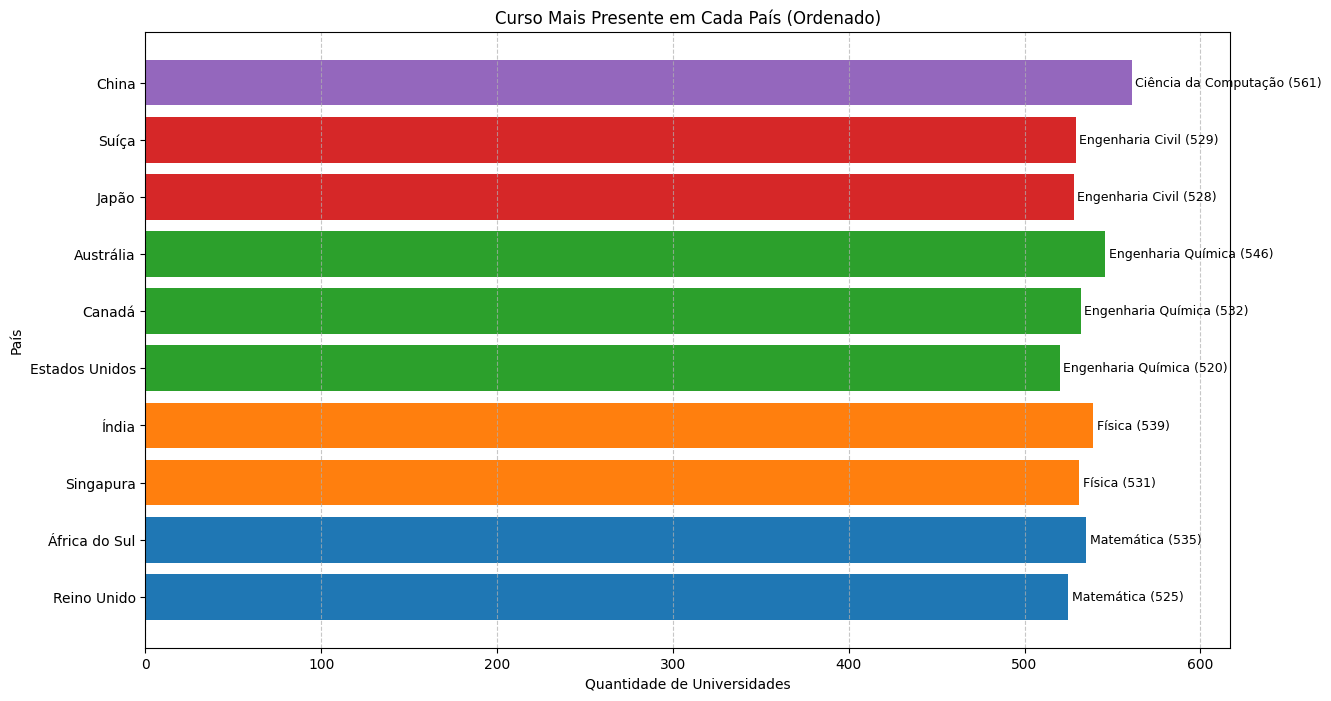

In [240]:
qtd_cursos_pais_order = qtd_cursos_pais.sort_values(by=['Curso Mais Presente', 'Quantidade'], ascending=[False, True])

cursos_unicos = qtd_cursos_pais_order['Curso Mais Presente'].unique()
cmap = plt.colormaps['tab10']
cores_cursos = {curso: cmap(i) for i, curso in enumerate(cursos_unicos)}

plt.figure(figsize=(14, 8))  
for pais, curso, qtd in zip(qtd_cursos_pais_order['Pais'], qtd_cursos_pais_order['Curso Mais Presente'], qtd_cursos_pais_order['Quantidade']):
    plt.barh(pais, qtd, color=cores_cursos[curso], height=0.8)  

plt.xlabel('Quantidade de Universidades')
plt.ylabel('País')
plt.title('Curso Mais Presente em Cada País (Ordenado)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.xlim(0, max(qtd_cursos_pais_order['Quantidade']) * 1.1)

for pais, curso, qtd in zip(qtd_cursos_pais_order['Pais'], qtd_cursos_pais_order['Curso Mais Presente'], qtd_cursos_pais_order['Quantidade']):
    plt.text(qtd + 2, pais, f'{curso} ({qtd})', va='center', fontsize=9, color='black')

plt.show()


### Quantidade média de cursos ofertados globalmente

In [241]:
qtd_cursos = dataset["Curso"].value_counts()
num_paises = dataset["Pais"].nunique()

media_cursos_global = (qtd_cursos / num_paises).round().astype(int)

media_cursos_global = media_cursos_global.to_frame(name='Media global de cursos ofertados')
media_cursos_global = media_cursos_global.sort_values(by='Media global de cursos ofertados', ascending=False)
media_cursos_global


,Media global de cursos ofertados
Curso,
Engenharia Química,513
Física,511
Matemática,507
Engenharia Elétrica,502
Ciência da Computação,501
Engenharia Civil,500
Biotecnologia,498
Administração de Empresas,496
Engenharia Mecânica,492


### Avaliação média de cada curso globalmente

In [242]:
aval_media_cursos_pais = (
    dataset.pivot_table(index='Pais', columns='Curso', values='CGPA', aggfunc='mean', fill_value=0)
    .round(2).reset_index()
)

aval_media_cursos_pais

Curso,Pais,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
0,Austrália,8.62,8.67,8.72,8.67,8.77,8.64,8.69,8.70,8.74,8.65
1,Canadá,8.64,8.67,8.70,8.66,8.75,8.78,8.77,8.72,8.83,8.74
2,China,8.73,8.69,8.68,8.71,8.70,8.80,8.79,8.74,8.66,8.71
3,Estados Unidos,8.68,8.72,8.71,8.73,8.65,8.66,8.78,8.71,8.65,8.72
4,Japão,8.69,8.67,8.71,8.68,8.76,8.69,8.69,8.68,8.72,8.67
5,Reino Unido,8.72,8.61,8.74,8.69,8.73,8.76,8.67,8.73,8.77,8.66
6,Singapura,8.67,8.71,8.70,8.76,8.72,8.71,8.68,8.70,8.73,8.72
7,Suíça,8.62,8.68,8.78,8.79,8.76,8.72,8.71,8.63,8.62,8.77
8,África do Sul,8.69,8.71,8.63,8.68,8.63,8.70,8.70,8.73,8.70,8.66
9,Índia,8.70,8.72,8.75,8.63,8.76,8.74,8.68,8.74,8.75,8.70


#### Quais cursos mais bem avaliados de cada país?

In [243]:
aval_media_cursos_pais['Curso Mais Presente'] = aval_media_cursos_pais.iloc[:, 1:].idxmax(axis=1)
aval_media_cursos_pais['Valor'] = aval_media_cursos_pais.iloc[:, 1:-1].max(axis=1)
aval_media_cursos_pais[['Pais', 'Curso Mais Presente', 'Valor']]

Curso,Pais,Curso Mais Presente,Valor
0,Austrália,Engenharia Civil,8.77
1,Canadá,Física,8.83
2,China,Engenharia Elétrica,8.80
3,Estados Unidos,Engenharia Mecânica,8.78
4,Japão,Engenharia Civil,8.76
5,Reino Unido,Física,8.77
6,Singapura,Economia,8.76
7,Suíça,Economia,8.79
8,África do Sul,Engenharia Química,8.73
9,Índia,Engenharia Civil,8.76


### Avaliação média global de cada curso

In [252]:
media_cgpa_por_curso = dataset.groupby("Curso")["CGPA"].mean().round(2)
media_cgpa_por_curso = media_cgpa_por_curso.to_frame(name="Média Global CGPA")
media_cgpa_por_curso.sort_values(by="Média Global CGPA", ascending=False)

,Média Global CGPA
Curso,
Engenharia Civil,8.72
Engenharia Elétrica,8.72
Física,8.72
Engenharia Mecânica,8.71
Engenharia Química,8.71
Ciência da Computação,8.71
Economia,8.70
Matemática,8.70
Biotecnologia,8.69


### Tamanho médio de turma por curso

In [245]:
qtd_prof_curso = dataset.pivot_table(values="Número_Professores", index="Pais", columns="Curso", aggfunc="mean")
qtd_aluno_curso = dataset.pivot_table(values="Total_Estudantes", index="Pais", columns="Curso", aggfunc="mean")
qtd_media_aluno_turma_pais = (qtd_aluno_curso / qtd_prof_curso).round().astype(int)
qtd_media_aluno_turma_pais

Curso,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
Pais,,,,,,,,,,
Austrália,31,32,32,32,32,32,31,31,31,31
Canadá,33,29,32,31,32,31,32,32,32,33
China,33,32,31,30,32,31,32,31,32,32
Estados Unidos,33,31,31,32,32,33,31,31,31,32
Japão,31,32,30,31,33,32,31,31,31,32
Reino Unido,31,31,30,32,31,30,31,31,32,31
Singapura,31,31,31,30,31,31,31,32,30,32
Suíça,31,31,32,31,31,32,30,31,31,32
África do Sul,33,31,31,31,32,31,31,31,32,31


### Media de pesquisas realizadas por curso

In [246]:
qtd_pesquisas_curso = dataset.pivot_table(values="Pesquisas_Publicadas", index="Pais", columns="Curso", aggfunc="mean")
qtd_pesquisas_curso = qtd_pesquisas_curso.round().astype(int)  # Arredonda e converte para inteiro
qtd_pesquisas_curso.fillna(0, inplace=True)  # Substitui NaN por 0
qtd_pesquisas_curso


Curso,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
Pais,,,,,,,,,,
Austrália,24,24,23,24,24,24,24,24,25,24
Canadá,24,24,24,24,24,24,26,24,25,25
China,25,25,24,24,24,24,23,26,25,24
Estados Unidos,24,25,25,25,24,24,25,24,25,25
Japão,24,26,25,24,25,25,25,25,24,24
Reino Unido,25,24,24,25,25,25,24,24,25,25
Singapura,24,23,24,23,26,25,24,25,25,25
Suíça,25,25,24,24,25,25,25,24,25,24
África do Sul,23,24,24,25,24,26,25,25,25,24


### Adicionando áreas de conhecimento ao dataset
Afim de um entendimento melhor, vamos categorizar os cursos por areas de conhecimento

In [247]:
dataset = dataset.copy()

dataset.loc[:, 'Area'] = dataset['Curso'].apply(lambda x: 
    'Engenharia' if x in ['Engenharia Química', 'Engenharia Elétrica', 
                           'Engenharia Civil', 'Engenharia Mecânica'] else
    'Ciências Exatas' if x in ['Física', 'Matemática', 'Ciência da Computação'] else
    'Ciências Sociais' if x in ['Economia', 'Administração de Empresas'] else
    'Ciências Biológicas' if x in ['Biotecnologia'] else
    'Outras')

##### Quantidade de áreas de conhecimento presente nas universidades de cada país

In [248]:
qtd_area_conhec_pais = (
    dataset.pivot_table(index='Pais', columns='Area', values='Curso', aggfunc='count', fill_value=0)
    .reset_index()
)

qtd_area_conhec_pais

Area,Pais,Ciências Biológicas,Ciências Exatas,Ciências Sociais,Engenharia
0,Austrália,506,1503,959,2050
1,Canadá,480,1530,984,1980
2,China,520,1585,996,1951
3,Estados Unidos,515,1463,978,2029
4,Japão,493,1490,957,2051
5,Reino Unido,488,1549,954,1954
6,Singapura,481,1531,1000,2001
7,Suíça,512,1484,976,2053
8,África do Sul,500,1546,979,2027
9,Índia,485,1504,980,1976


#### Gráfico

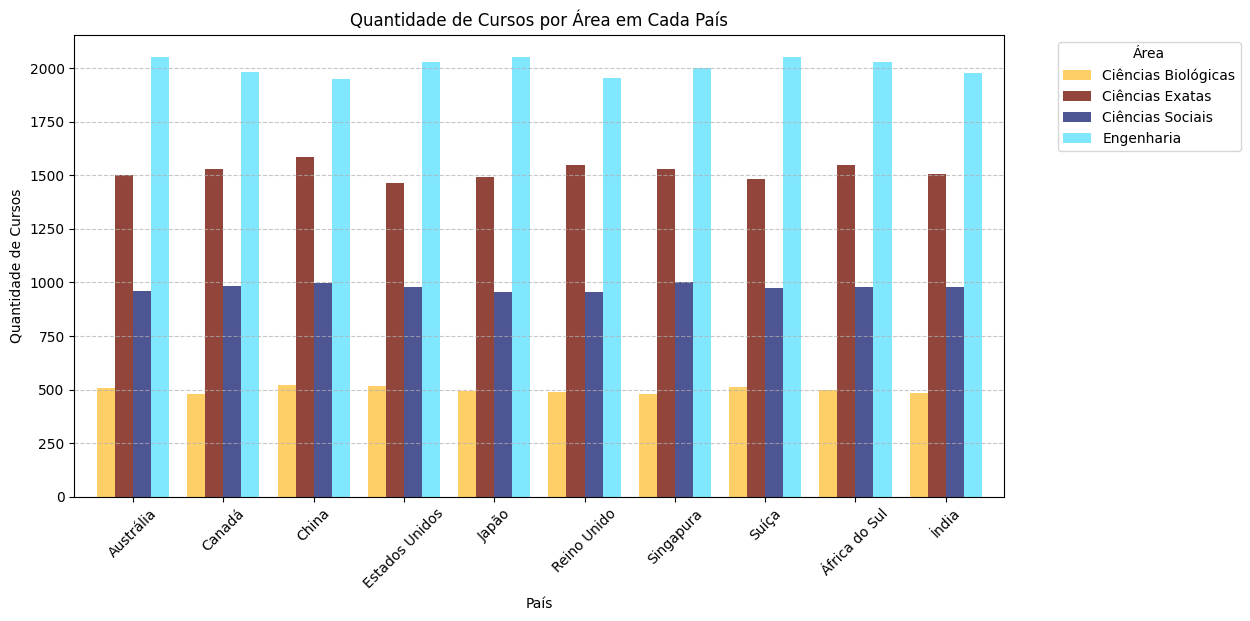

In [249]:
qtd_area_conhec_pais.set_index('Pais').plot(kind='bar', figsize=(12, 6), colormap='managua', width=0.8)

plt.xlabel('País')
plt.ylabel('Quantidade de Cursos')
plt.title('Quantidade de Cursos por Área em Cada País')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Área', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


# Analise de correlação

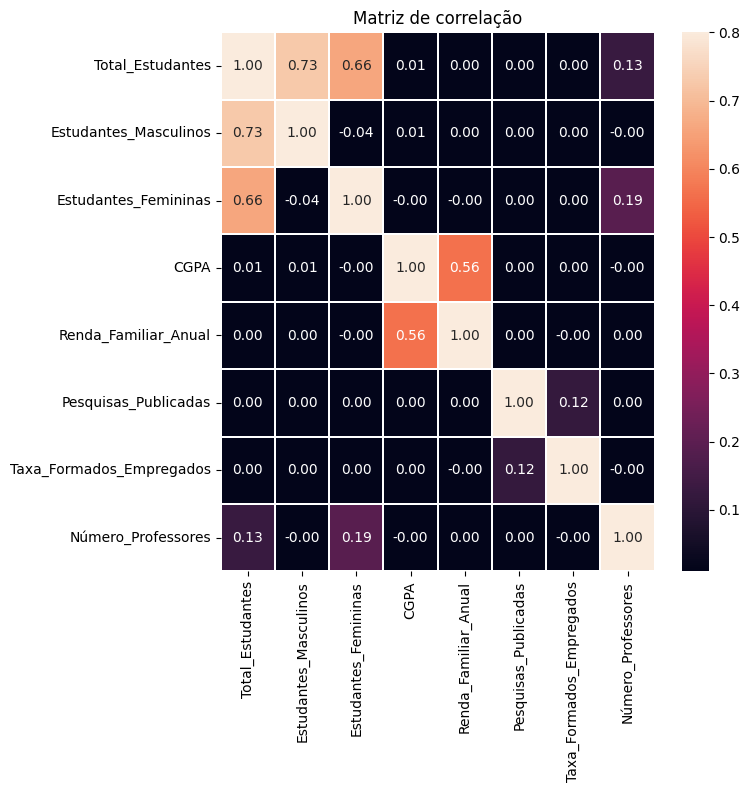

In [250]:
correlacao = dataset.fillna(0).corr(numeric_only=True)
correlacao_formatada = correlacao.map(lambda x: '{:.2f}'.format(x))

plt.figure(figsize=(7,7))
sns.heatmap(correlacao, annot=correlacao_formatada, fmt='', vmin=0.01, vmax=0.8, linewidths=0.1)
plt.title('Matriz de correlação')
plt.show()